# Health, logs, and workload observability

CPU companion; no accelerator is required. TPU execution not validated.

- Build useful summaries from structured events emitted by a real worker.
- Define throughput with explicit numerator, denominator and synchronization boundary.
- Estimate uncheckpointed work from progress and checkpoint events.

A process is alive and prints messages, yet useful training may have stopped. What signals distinguish real progress from noise, and what could be lost if the process fails now? We will measure synchronized updates, count examples and compare progress with the latest committed checkpoint using events emitted by actual runs.

## The idea

Logs tell us what a process reported; accepted checkpoints tell us what can be resumed. Monitoring should connect these signals without treating them as interchangeable. Their difference helps estimate the consequences of a failure.

## Keep observed progress separate from recoverable progress

If the live process reports step 42 and the newest accepted checkpoint is step 40, there are two completed steps beyond that recovery boundary. Whether they must be replayed depends on the recovery contract and recorded input state.

Name metric units and update points: examples processed, valid tokens, optimizer steps and accepted checkpoint steps are different counters. A sudden flat line can indicate stalled computation, blocked logging or a failed collector; inspect another signal before assigning the cause.

Read the two progress curves at the same time coordinate and locate the failure. The gap describes lag in recoverable progress, while the slope of live progress describes reported work rate. Neither alone proves hardware utilization.

### Pause and reason

Does a recent log line prove that its reported step is durable?

<details><summary>Compare your reasoning</summary>

No. It proves the observation reached the log. Recovery durability depends on the accepted checkpoint and storage contract.

</details>

## An event needs meaning and units

Each event has a monotonic timestamp and an event name. A progress event adds completed step, scalar loss, examples processed, synchronized update seconds and a hash of the resulting complete state. Checkpoint events record the step that was actually replaced on disk. A heartbeat would show liveness only; it must not increment examples or claim training progress. Monotonic time is useful for local durations but is not a globally comparable timestamp across unrelated hosts.

## Time completed computation

JAX may return control before an operation finishes. The worker calls block_until_ready on the result before stopping its update timer. That timer includes dispatch and completion of one compiled minibatch update, but excludes JSON encoding, checkpoint writes, process startup and compilation. The ready event records a separate compile/warmup duration. A benchmark that times dispatch alone would understate service time.

## Two throughputs answer different questions

For $12$ updates of $8$ examples, the numerator is $96$ examples. Divide by the sum of synchronized update durations to describe the update path. Divide by supervisor wall time to describe the short job end to end. The latter is lower here because this tiny workload spends much of its lifetime outside the compiled updates. Neither rate should be relabeled as a device hardware utilization percentage.

$$
q_{\mathrm{update}}=\frac{N}{\sum_i t_i},\qquad q_{\mathrm{job}}=\frac{N}{T_{\mathrm{wall}}}
$$

## Freshness is about committed progress

The controlled incident fails after update $5$, while the checkpoint cadence is every $2$ updates. Its last committed checkpoint is step $4$, leaving one completed but uncommitted update. This is a count of potential replay work, not a time-based recovery objective. To express time at risk, use appropriate measured durations and explicitly distinguish completed work from work that might still be in flight.

$$
\mathrm{uncommitted\ updates}=\max(0,\mathrm{last\ progress\ step}-\mathrm{checkpoint\ step})
$$

## A declining loss is not a health guarantee

The fixture fits a line with minibatch momentum updates. Loss may rise between batches because different examples are sampled, and momentum can overshoot. A lower recent loss does not prove input freshness, checkpoint durability or correct evaluation. Conversely, a noisy loss sequence does not prove a stalled process. Diagnose loss behavior using the optimization lessons; diagnose missing progress using event and process evidence.

## Scope of this collector

This bounded lab captures stdout and stderr in memory and analyzes events after the child exits. That is appropriate for a few dozen events. A long-running service needs streamed, bounded logs, a durable sink, timestamps aligned for its fleet, and monitored queue/backpressure behavior. The lesson provides measurement contracts and actual failure evidence, not an operational telemetry backend.

## Create the local artifact helpers

Create main.py with this block. Run python3 main.py in the CPU course environment.

In [1]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

The only filesystem writes are to the caller-selected run directory. Stable JSON encoding makes hashes reproducible.

## Define the supervised worker

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [2]:
# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

The string is a real Python program launched in a separate process. It emits structured events, synchronizes JAX updates and preserves complete state.

## Add bounded launch and result collection

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [3]:
def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

The supervisor owns the child handle, captures its output and always waits for termination after a timeout.

## Summarize event boundaries

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [4]:
def summarize(result):
    updates=[e for e in result['events'] if e['event']=='progress']
    checkpoints=[e['step'] for e in result['events'] if e['event']=='checkpoint']
    count=sum(e['examples'] for e in updates);update_s=sum(e['update_s'] for e in updates)
    latest=max((e['step'] for e in updates),default=0)
    checkpoint=max(checkpoints,default=0)
    return dict(status=result['status'],updates=len(updates),examples=count,last_step=latest,checkpoint_step=checkpoint,
                uncheckpointed_updates=max(0,latest-checkpoint),update_s=update_s,
                update_examples_per_s=count/update_s if update_s else 0.,
                job_examples_per_s=count/result['wall_s'] if result['wall_s'] else 0.,
                update_duty_fraction=update_s/result['wall_s'] if result['wall_s'] else 0.)

The summary retains work counts, timing boundaries and checkpoint lag separately.

## Run a healthy job and a controlled incident

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [5]:
with tempfile.TemporaryDirectory(prefix='ops-signals-') as folder:
    observed=launch(Path(folder)/'healthy',dict(steps=12))
    interrupted=launch(Path(folder)/'failed',dict(steps=12,fail_after=5))
healthy=summarize(observed); incident=summarize(interrupted)
progress=[e for e in observed['events'] if e['event']=='progress']
assert healthy['examples']==96 and healthy['updates']==12
assert incident['last_step']==5 and incident['checkpoint_step']==4
assert incident['uncheckpointed_updates']==1
assert healthy['job_examples_per_s'] < healthy['update_examples_per_s']
print('healthy:',healthy)
print('incident:',incident)

healthy: {'status': 'completed', 'updates': 12, 'examples': 96, 'last_step': 12, 'checkpoint_step': 12, 'uncheckpointed_updates': 0, 'update_s': 0.00045341532677412033, 'update_examples_per_s': 211726.4113743219, 'job_examples_per_s': 122.06947168994397, 'update_duty_fraction': 0.0005765434312025018}
incident: {'status': 'failed', 'updates': 5, 'examples': 40, 'last_step': 5, 'checkpoint_step': 4, 'uncheckpointed_updates': 1, 'update_s': 0.0002157897688448429, 'update_examples_per_s': 185365.60011221285, 'job_examples_per_s': 55.20281340973716, 'update_duty_fraction': 0.00029780505863180443}


Both summaries are derived from real child output; failures are not invented status rows.

## Run the example

In [6]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

def summarize(result):
    updates=[e for e in result['events'] if e['event']=='progress']
    checkpoints=[e['step'] for e in result['events'] if e['event']=='checkpoint']
    count=sum(e['examples'] for e in updates);update_s=sum(e['update_s'] for e in updates)
    latest=max((e['step'] for e in updates),default=0)
    checkpoint=max(checkpoints,default=0)
    return dict(status=result['status'],updates=len(updates),examples=count,last_step=latest,checkpoint_step=checkpoint,
                uncheckpointed_updates=max(0,latest-checkpoint),update_s=update_s,
                update_examples_per_s=count/update_s if update_s else 0.,
                job_examples_per_s=count/result['wall_s'] if result['wall_s'] else 0.,
                update_duty_fraction=update_s/result['wall_s'] if result['wall_s'] else 0.)

with tempfile.TemporaryDirectory(prefix='ops-signals-') as folder:
    observed=launch(Path(folder)/'healthy',dict(steps=12))
    interrupted=launch(Path(folder)/'failed',dict(steps=12,fail_after=5))
healthy=summarize(observed); incident=summarize(interrupted)
progress=[e for e in observed['events'] if e['event']=='progress']
assert healthy['examples']==96 and healthy['updates']==12
assert incident['last_step']==5 and incident['checkpoint_step']==4
assert incident['uncheckpointed_updates']==1
assert healthy['job_examples_per_s'] < healthy['update_examples_per_s']
print('healthy:',healthy)
print('incident:',incident)

healthy: {'status': 'completed', 'updates': 12, 'examples': 96, 'last_step': 12, 'checkpoint_step': 12, 'uncheckpointed_updates': 0, 'update_s': 0.0006278324872255325, 'update_examples_per_s': 152907.02847225312, 'job_examples_per_s': 115.36362596492852, 'update_duty_fraction': 0.0007544690856762197}
incident: {'status': 'failed', 'updates': 5, 'examples': 40, 'last_step': 5, 'checkpoint_step': 4, 'uncheckpointed_updates': 1, 'update_s': 0.0002914145588874817, 'update_examples_per_s': 137261.50180246978, 'job_examples_per_s': 53.27409255440097, 'update_duty_fraction': 0.0003881211545467908}


Expected: The healthy run records $96$ processed examples. The failure occurs at step $5$, with checkpoint step $4$, so one completed update must be replayed.

## Observed progress and committed progress diverge before failure

Predict: Will the checkpoint line always equal the progress line?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [7]:
committed=0;points=[];saved=[]
for event in interrupted['events']:
    if event['event']=='checkpoint': committed=event['step']
    if event['event']=='progress':
        points.append(event['step']);saved.append(committed)
# At each completed step include a checkpoint emitted immediately afterward.
for i,step_number in enumerate(points):
    saved[i]=max([e['step'] for e in interrupted['events'] if e['event']=='checkpoint' and e['step']<=step_number],default=0)
visual_data={'kind':'line','x':points,'xlabel':'completed update number','ylabel':'step index','series':[{'label':'observed progress','y':points},{'label':'committed checkpoint','y':saved}]}

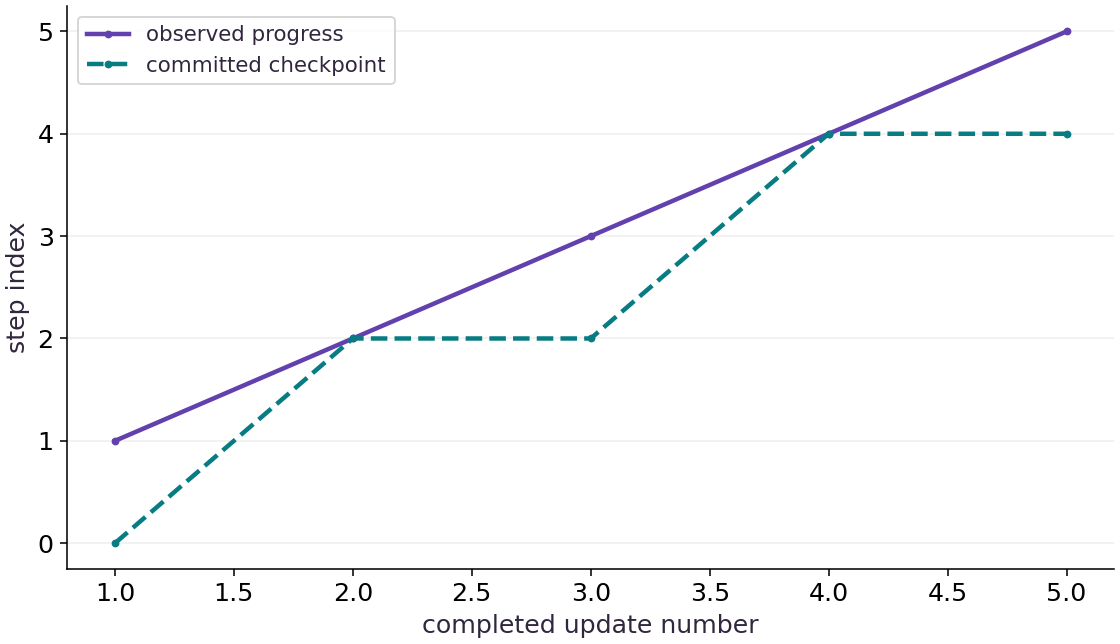

In [8]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is completed update number for the failed run. The vertical axis is step index. The progress line reaches $5$, while the checkpoint line advances at steps $2$ and $4$, ending at $4$. The vertical gap at the final point is one update. These values come from actual emitted events, not a hypothetical fleet trace.

### Connect it to the computation

The staircase records when state becomes available for recovery. A gap is expected between checkpoints; it becomes operationally relevant when the process fails. Resuming from step $4$ repeats update $5$ using its restored optimizer and random state. This plot does not show elapsed recovery time or prove power-loss durability.

## Recompute throughput independently

Predict: Should averaging per-step rates equal total examples divided by total time?

In [9]:
total_examples=sum(e['examples'] for e in progress)
total_time=sum(e['update_s'] for e in progress)
assert abs(total_examples/total_time-healthy['update_examples_per_s']) < 1e-6
assert all(e['update_s']>0 for e in progress)
print('examples / synchronized seconds:',total_examples,total_time)

examples / synchronized seconds: 96 0.0006278324872255325


Expected: The summary matches the independently accumulated numerator and denominator.

Summing work and time weights slow steps appropriately; an unweighted mean of rates generally answers a different question.

## Locate the incident boundary

Predict: Is the last successful update necessarily present in the checkpoint?

In [10]:
names=[e['event'] for e in interrupted['events']]
assert names[-1]=='failed'
assert [e['step'] for e in interrupted['events'] if e['event']=='checkpoint']==[2,4]
assert [e['step'] for e in interrupted['events'] if e['event']=='progress'][-1]==5

Expected: The event order exposes exactly one completed update after the latest checkpoint.

A progress log is not a committed state artifact. Recovery must select the committed boundary.

## Your exercise

Compute the fraction of supervisor wall time spent inside synchronized updates, and state precisely what that fraction excludes.

In [11]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [12]:
duty=sum(e['update_s'] for e in progress)/observed['wall_s']
assert 0 < duty < 1
assert abs(duty-healthy['update_duty_fraction']) < 1e-9
print('measured update duty fraction, not hardware utilization:',duty)

measured update duty fraction, not hardware utilization: 0.0007544690856762197


## Catch an average-of-rates error · Transfer / diagnosis

Two updates process $8$ examples each in $1$ and $3$ seconds. Compare the average rate with the rate of all completed work.

Hint: Sum examples and seconds first.

In [13]:
# Write your attempt here.

## Reference reasoning

The short step gets excessive influence when rates are averaged without accounting for their duration.

In [14]:
durations=[1.,3.];counts=[8,8]
wrong=sum(n/t for n,t in zip(counts,durations))/2
right=sum(counts)/sum(durations)
assert abs(wrong-16/3)<1e-12 and right==4.

## Change the checkpoint cadence · Transfer / diagnosis

Run with checkpoint cadence $3$ and fail after update $5$. Predict the committed step and replay count.

Hint: Expect the most recent multiple of the checkpoint interval before the failure.

In [15]:
# Write your attempt here.

## Reference reasoning

The run tests a changed operational policy rather than assuming every failure loses exactly one update.

In [16]:
with tempfile.TemporaryDirectory() as folder:
    changed=launch(folder,dict(checkpoint_every=3,fail_after=5))
stats=summarize(changed)
assert stats['checkpoint_step']==3 and stats['uncheckpointed_updates']==2

## Checkpoint

What does update duty fraction establish in this lab?

1. GPU compute-unit occupancy
2. Cluster utilization across hosts
3. The fraction of this job’s wall time inside the measured synchronized update boundary

## Diagnose

If throughput is implausibly high, check synchronization and whether examples were counted twice. If checkpoint freshness looks perfect during a failure, verify that checkpoint events are emitted only after replacement completes. If timestamps appear out of order across hosts, do not subtract unrelated monotonic clocks.

## Evidence

Keep raw structured events, observed work counts, synchronized timing units and checkpoint lag. Derive job and update throughput with different boundaries.

## Carry forward

- Choose metrics that answer a concrete operational decision.
- Specify the timing boundary before reporting a throughput or utilization-like ratio.

## Primary references

- [Python subprocess management](https://docs.python.org/3/library/subprocess.html)
- [Python os.replace and fsync](https://docs.python.org/3/library/os.html#os.replace)
- [JAX asynchronous dispatch and synchronization](https://docs.jax.dev/en/latest/async_dispatch.html)
- [JAX device discovery](https://docs.jax.dev/en/latest/_autosummary/jax.devices.html)